In questo esercizio si interpola una prima funzione di prova tramite interpolazione lineare su nodi e si analizza l’errore di interpolazione. Nella seconda parte si calcola la derivata di una seconda funzione di prova usando due metodi numerici (a 2 e 4 punti) e si confrontano gli errori al variare del passo h.

Interpolazione

In [ ]:
import numpy as np  
import matplotlib.pyplot as plt

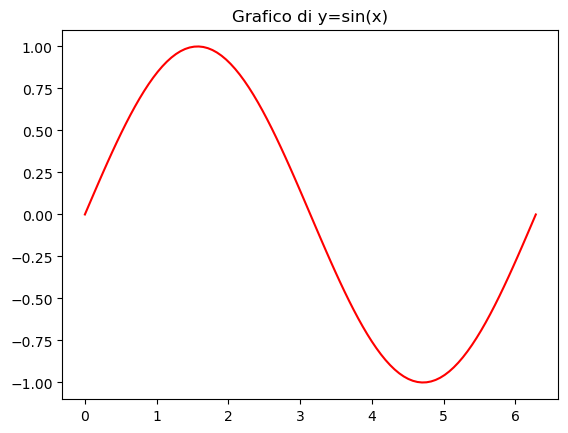

In [2]:
fx=lambda x: np.sin(x)   #permette di scrivere funzionbe in una sola riga, a sx dei due punti sono arg, a dx è quello che deve fare la funzione

x_points=np.linspace(0,2*np.pi,100)
y_points=fx(x_points)
plt.plot(x_points,y_points, color='red')
plt.title('Grafico di y=sin(x)')
plt.show()

In [3]:
def linear_interpolation(x,x_nodes,y_nodes): # x = punti da interpolare, x_nodes = nodi, y_nodes = valori della funzione nei nodi
    index=np.digitize(x,x_nodes)-1 # Trova il bin a cui appartiene ogni x
    y=y_nodes[index]+(y_nodes[index+1]-y_nodes[index])/(x_nodes[index+1]-x_nodes[index])*(x-x_nodes[index])  # Formula di interpolazione lineare
    return y

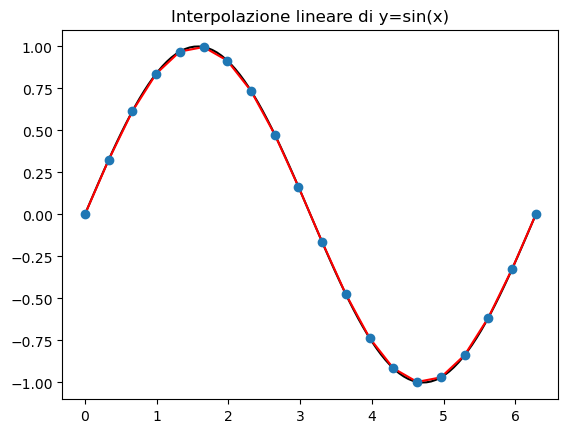

In [4]:
x_nodes=np.linspace(0,2*np.pi,20) 
y_nodes=fx(x_nodes)

x_interp=np.linspace(0,2*np.pi*0.999,100) # non includo il bordo destro per evitare problemi di indicizzazione
y_interp=linear_interpolation(x_interp,x_nodes,y_nodes)

plt.plot(x_points,y_points,color='k')
plt.plot(x_interp,y_interp, color='red')
plt.plot(x_nodes,y_nodes,'o')
plt.title('Interpolazione lineare di y=sin(x)')
plt.show()

In [5]:
# Confronto tra funzione vera e interpolazione
y_true=fx(x_interp)
diff=np.abs(y_interp-y_true)

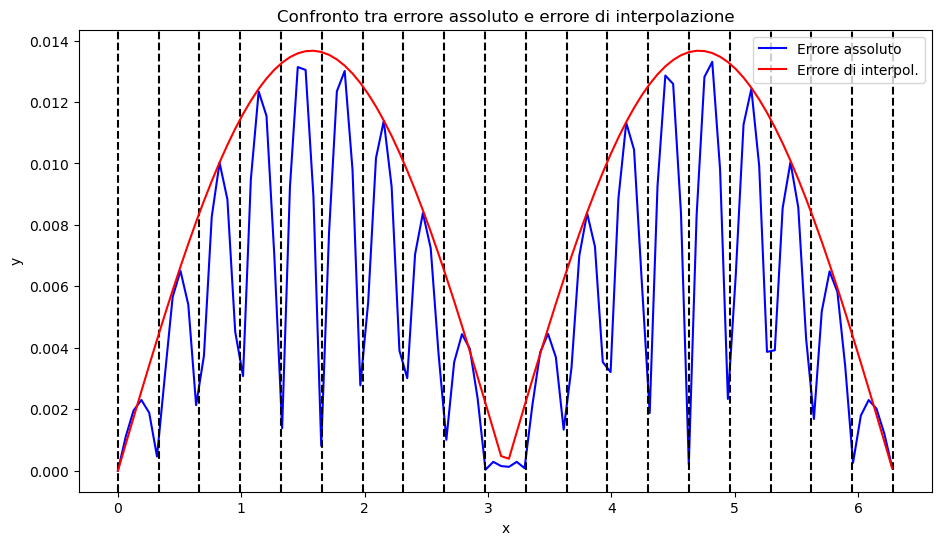

In [6]:
plt.figure(figsize=(11, 6))
plt.plot(x_interp,diff, color='blue', label='Errore assoluto') # Grafico dell’errore assoluto in funzione di x
plt.xlabel('x')
plt.ylabel('y')
for i in range(len(x_nodes)):
    plt.axvline(x=x_nodes[i],color='k',linestyle='--') # Aggiunge linee verticali sui nodi
plt.plot(x_interp, np.abs(np.sin(x_interp)*(x_nodes[1]-x_nodes[0])**2/8), color='red',label= 'Errore di interpol.' ) # Sovrappongo grafico dell'errore di interpolazione
plt.legend(loc='upper right')
plt.title('Confronto tra errore assoluto e errore di interpolazione')
plt.show()

NB: l’errore assoluto è nullo nei nodi, dove l’interpolazione lineare coincide con la funzione originale. Tra i nodi, invece, l’errore cresce perché la retta usata per interpolare non segue bene l’andamento curvo della funzione. L’errore massimo si ha proprio dove la funzione curva di più, cioè vicino ai picchi.

Derivazione con due metodi diversi: primo è metodo centrale a 2 punti, secondo è metoodo centrale a 4 punti

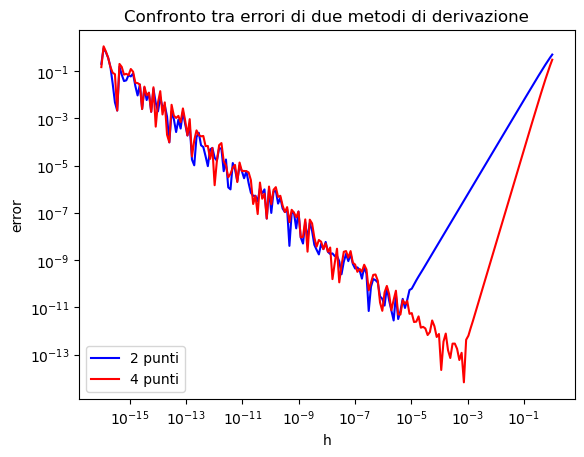

In [7]:
hlist=np.logspace(-16,0,200) # Lista di passi h da 10^-16 a 10^0
fx=lambda x: np.sin(x)**2

x_cen=1 # Punto centrale in cui calcolare la derivata
err_1=[] # Lista per errori del primo metodo
err_2=[] # Lista per errori del secondo metodo

for i in range(len(hlist)):

    diff_1=(fx(x_cen +hlist[i])-fx(x_cen-hlist[i]))/(2*hlist[i]) # Derivata centrale a 2 punti
    diff_2=(2./3*fx(x_cen +hlist[i])-2./3*fx(x_cen-hlist[i])-1./12*fx(x_cen +2*hlist[i])+1./12*fx(x_cen-2*hlist[i]))/(hlist[i]) # Derivata centrale a 4 punti
    err_1.append(np.abs(diff_1-2*np.sin(x_cen)*np.cos(x_cen))) 
    err_2.append(np.abs(diff_2-2*np.sin(x_cen)*np.cos(x_cen)))

plt.loglog(hlist,err_1,color='blue',label='2 punti')
plt.loglog(hlist,err_2,color='red',label='4 punti')
plt.legend()
plt.xlabel('h')
plt.ylabel('error')
plt.title('Confronto tra errori di due metodi di derivazione')
plt.show()

NB: All’aumentare di h (verso destra), l’approssimazione peggiora e l’errore cresce. Quando h diminuisce, l’errore cala e raggiunge un minimo, ma se h diventa troppo piccolo, l’errore risale per via degli arrotondamenti numerici: infatti se h è troppo piccolo, la differenza f(x+h)−f(x−h) diventa molto vicina a zero, e anche il denominatore h è minuscolo. Questo rende il rapporto numericamente instabile: il computer perde precisione nei calcoli e l’errore invece di diminuire, aumenta.
In conclusione, il metodo a 4 punti (rosso) risulta più preciso del metodo a 2 punti (blu), perché raggiunge errori più bassi grazie a un’approssimazione più accurata.